# Problem Overview

### How to accurately identify and reduce the most significant risk factors of heart disease in a large, diverse population, using tools like machine learning to enhance prevention and early detection


### Why is it important to solve?
#### High prevalence of heart disease and its major risk factors among the U.S. population, and the need for improved identification and prevention strategies

# Getting Started

In [624]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import json

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


colors = ['skyblue', 'salmon', 'lightgreen', 'lightcoral', 'lightblue', 'lightyellow', 'lightpink', 'lightgray']


In [625]:

df = pd.read_csv('./data/heart_2022_with_nans.csv')

df.sample(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
420296,West Virginia,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,...,1.91,86.18,23.75,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
196434,Minnesota,Female,Good,0.0,10.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.70,95.25,32.89,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
195197,Minnesota,Female,Poor,30.0,15.0,Within past year (anytime less than 12 months ...,No,13.0,None of them,No,...,1.65,45.36,16.64,Yes,Yes,Yes,No,NaN,No,Yes
208443,Minnesota,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.63,49.90,18.88,Yes,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
176061,Massachusetts,Male,Very good,2.0,4.0,Within past 2 years (1 year but less than 2 ye...,Yes,7.0,None of them,No,...,1.83,69.40,20.75,Yes,No,No,No,"Yes, received Tdap",No,Yes
363385,Utah,Male,Very good,1.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,No,...,1.70,95.25,32.89,No,Yes,Yes,Yes,NaN,No,No
38104,Colorado,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.73,72.57,24.33,Yes,No,Yes,No,"No, did not receive any tetanus shot in the pa...",No,No
38164,Colorado,Male,Good,1.0,5.0,Within past 5 years (2 years but less than 5 y...,No,5.0,1 to 5,No,...,1.68,104.33,37.12,No,Yes,Yes,No,"No, did not receive any tetanus shot in the pa...",No,Yes
159131,Maryland,Female,Very good,0.0,5.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,NaN,NaN,NaN,Yes,Yes,Yes,No,"Yes, received Tdap",Yes,No
381826,Virginia,Male,Fair,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,1 to 5,No,...,1.83,88.45,26.45,Yes,No,Yes,Yes,NaN,No,Yes


In [626]:
df.shape

(445132, 40)

In [627]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

## EDA
### 1. Understand the Problem & Dataset
#### 1.1 Define Business Objective
#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images
### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers
#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers
    1. IQR method / Z-score
    2. Box plots
#### 4. Univariate Analysis
1. For Numeric features check distribution
2. For Categorical features check Frequency count
#### 5. [Bivariate Analysis](#bivariate-analysis)
1. Numerical v/s Target  
    1. Box plot
2. Categorical v/s Target  
    1. Count plot
#### 6. Multivariate Analysis
1. Correlation heatmaps for numeric features
2. Detect multicollinearity
#### 7. Encoding Categorical Features
1. Label Encoding for Ordinal categories
2. One-Hot Encoding for Nominal categories 
#### 8. Feature Scaling 
1. StandardScaler
#### 9. Feature Selection
1. Identify most relevant features 
    1. Is PCA good option?
#### 10. Feature Engineering
1. Create new meaningful features 
#### 11. Train-Test split 


###################################################################################################################################################

#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images

<span style="color: green; font-weight: bold; font-size:20px">Target variable is "HadHeartAttack"</span>


In [628]:
target_variable = "HadHeartAttack"

<span style="color: green; font-weight: bold; font-size:16px">List if Numeric columns</span>


In [629]:
numeric_columns = df.select_dtypes(exclude='object').columns
print(f"Numerical columns: {numeric_columns.to_list()} ")
print("-" * 120)

Numerical columns: ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI'] 
------------------------------------------------------------------------------------------------------------------------


<span style="color: green; font-weight: bold; font-size:16px">List if Non-Numeric columns</span>

In [630]:
# List columns with type as Object
object_columns = df.select_dtypes(include='object').columns.sort_values()
print("Object columns:", list(object_columns))
print("-" * 40)

# For loop to get unique values of each object column and print the results
# for col in object_columns.sort_values():
#     # print(f"Unique values in column '{col}':")
#     # print(df[col].unique())
#     print(df[col].value_counts(dropna=False, ascending=True))
#     print("-" * 40)


Object columns: ['AgeCategory', 'AlcoholDrinkers', 'BlindOrVisionDifficulty', 'ChestScan', 'CovidPos', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'DifficultyDressingBathing', 'DifficultyErrands', 'DifficultyWalking', 'ECigaretteUsage', 'FluVaxLast12', 'GeneralHealth', 'HIVTesting', 'HadAngina', 'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder', 'HadDiabetes', 'HadHeartAttack', 'HadKidneyDisease', 'HadSkinCancer', 'HadStroke', 'HighRiskLastYear', 'LastCheckupTime', 'PhysicalActivities', 'PneumoVaxEver', 'RaceEthnicityCategory', 'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap']
----------------------------------------


<span style="color: green; font-weight: bold; font-size:16px">Identified Boolean columns</span>


In [631]:
boolean_columns = ["AlcoholDrinkers", "BlindOrVisionDifficulty", "ChestScan", "DeafOrHardOfHearing", "DifficultyConcentrating","DifficultyDressingBathing", "DifficultyErrands","DifficultyWalking", "FluVaxLast12", "HIVTesting", "HadAngina", "HadArthritis", "HadAsthma", "HadCOPD", "HadDepressiveDisorder", "HadKidneyDisease", "HadSkinCancer", "HadStroke", "HighRiskLastYear", "PhysicalActivities", "PneumoVaxEver"]

for col in boolean_columns:
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

AlcoholDrinkers
Yes    210891
No     187667
NaN     46574
Name: count, dtype: int64
----------------------------------------
BlindOrVisionDifficulty
No     399910
Yes     23658
NaN     21564
Name: count, dtype: int64
----------------------------------------
ChestScan
No     223221
Yes    165865
NaN     56046
Name: count, dtype: int64
----------------------------------------
DeafOrHardOfHearing
No     385539
Yes     38946
NaN     20647
Name: count, dtype: int64
----------------------------------------
DifficultyConcentrating
No     370792
Yes     50100
NaN     24240
Name: count, dtype: int64
----------------------------------------
DifficultyDressingBathing
No     404404
NaN     23915
Yes     16813
Name: count, dtype: int64
----------------------------------------
DifficultyErrands
No     387029
Yes     32447
NaN     25656
Name: count, dtype: int64
----------------------------------------
DifficultyWalking
No     353039
Yes     68081
NaN     24012
Name: count, dtype: int64
-------------

### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers

<span style="color: green; font-weight: bold; font-size:16px">Check column wise % of Null value records</span>


In [632]:
# Percentage of null values in each column
nan_percent = df.isna().mean().mul(100).to_frame('NaN %')

nan_percent.sort_values(by='NaN %', ascending=False)


,NaN %
TetanusLast10Tdap,18.537423
PneumoVaxEver,17.307226
HIVTesting,14.855593
ChestScan,12.590872
CovidPos,11.404258
HighRiskLastYear,11.372582
BMI,10.964388
FluVaxLast12,10.585849
AlcoholDrinkers,10.462964
WeightInKilograms,9.452926



<span style="color:red"># Note:Following columns may be dropped because it has more than 15% of the rows with No Data</span> 


In [633]:
# Query nan_percent to give records which are more than 15%
high_nan = nan_percent[nan_percent['NaN %'] > 15].sort_values(by='NaN %', ascending=False)
print(high_nan)


                       NaN %
TetanusLast10Tdap  18.537423
PneumoVaxEver      17.307226


<span style="color: green; font-weight: bold; font-size:16px">Finding number of rows with all NULL values and number of duplicates</span>

In [634]:
# Number of rows with all NULL values

num_rows_all_null = df.isnull().all(axis=1).sum()
print(f"Number of rows with all columns NULL: {num_rows_all_null}")
print("-" * 120)

# Find duplicate records in the dataframe
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of duplicate records: {len(duplicate_rows)}")
if not duplicate_rows.empty:
    print("Sample duplicate records:")
    display(duplicate_rows.head())


Number of rows with all columns NULL: 0
------------------------------------------------------------------------------------------------------------------------
Number of duplicate records: 302
Sample duplicate records:


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
4712,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7310,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10696,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
11503,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
26789,California,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<span style="color: green; font-weight: bold; font-size:16px">Check for outliers in numeric data columns using IQR method</span>

Outlier summary for numeric columns:


,Column,Num Outliers,Percent Outliers,Max Outlier,Min Outlier
3,PhysicalHealthDays,72269,16.64,30.00,8.00
2,MentalHealthDays,60389,13.85,30.00,13.00
0,BMI,12339,3.11,99.64,12.02
5,WeightInKilograms,9643,2.39,292.57,22.68
4,SleepHours,7260,1.65,24.00,1.00
1,HeightInMeters,1556,0.37,2.41,0.91


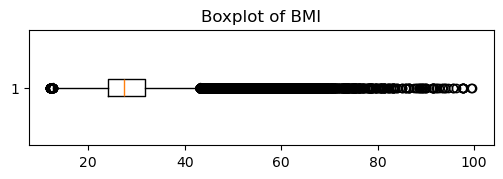

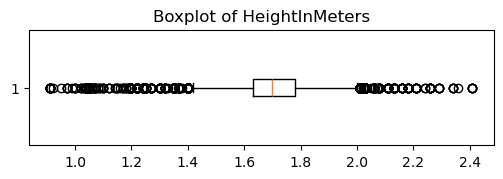

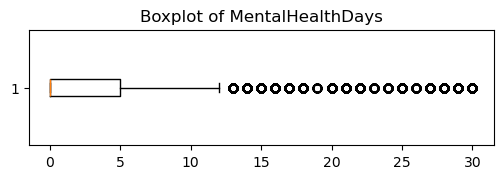

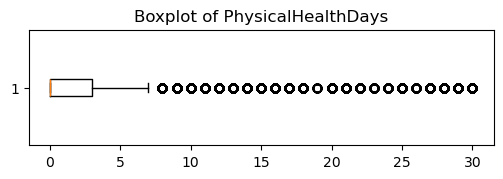

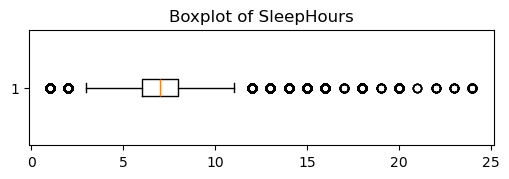

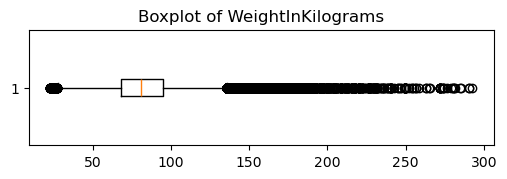

In [635]:
# Check for outliers in numeric data columns using IQR method

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.sort_values()

# print(numeric_columns)

outlier_summary = pd.DataFrame(columns=["Column", "Num Outliers", "Percent Outliers", "Max Outlier", "Min Outlier"])

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    num_outliers = outliers.count()
    percent_outliers = (num_outliers / df[col].count()) * 100 if df[col].count() > 0 else 0
    max_outlier = outliers.max()
    min_outlier = outliers.min()        
    outlier_summary.loc[len(outlier_summary)] = [col, num_outliers, round(percent_outliers, 2), max_outlier, min_outlier]

print("Outlier summary for numeric columns:")
display(outlier_summary.sort_values(by="Percent Outliers", ascending=False))

# Visualize outliers for each numeric column
import matplotlib.pyplot as plt
for col in numeric_columns:
    plt.figure(figsize=(6, 1.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()


<span style="color: green; font-weight: bold; font-size:16px">Check for outliers in numeric data columns using Z-score method</span>

In [636]:
from scipy.stats import zscore

# Calculate Z-scores for numeric columns
z_scores = df[numeric_columns].dropna().apply(zscore)

# print(z_scores)

# Set a threshold for Z-score to identify outliers (commonly 3 or -3)
z_threshold = 3

z_outlier_summary = pd.DataFrame(columns=["Column", "Num Outliers", "Percent Outliers", "Max Z", "Min Z"])

for col in numeric_columns:
    # Find outliers based on Z-score
    outliers = z_scores[(z_scores[col].abs() > z_threshold)][col]
    num_outliers = outliers.count()
    percent_outliers = (num_outliers / df[col].count()) * 100 if df[col].count() > 0 else 0
    max_z = df[col].max()
    min_z = df[col].min()
    z_outlier_summary.loc[len(z_outlier_summary)] = [col, num_outliers, round(percent_outliers, 2), round(max_z, 2), round(min_z, 2)]

print("Outlier summary for numeric columns using Z-Score:")
display(z_outlier_summary.sort_values(by="Percent Outliers", ascending=False))


Outlier summary for numeric columns using Z-Score:


,Column,Num Outliers,Percent Outliers,Max Z,Min Z
2,MentalHealthDays,22929,5.26,30.00,0.00
4,SleepHours,5899,1.34,24.00,1.00
0,BMI,4806,1.21,99.64,12.02
5,WeightInKilograms,3960,0.98,292.57,22.68
1,HeightInMeters,824,0.20,2.41,0.91
3,PhysicalHealthDays,0,0.00,30.00,0.00


<span style="color: brown; font-weight: bold; font-size:20px">##After analyzing outlier results, I have decided not to remove All the outlier data because to be those outliers seems to be valid data. For example WeightInKg can be 292.57, but HeightInMeters of .91 meters (3 feet) seems to eb non realistic, same for SleepHours of 24 hours</span>

### Univariate analysis
<span style="color: green; font-weight: bold; font-size:16px">Plot histogram for all numeric columns except "HadHeartAttack"</span>

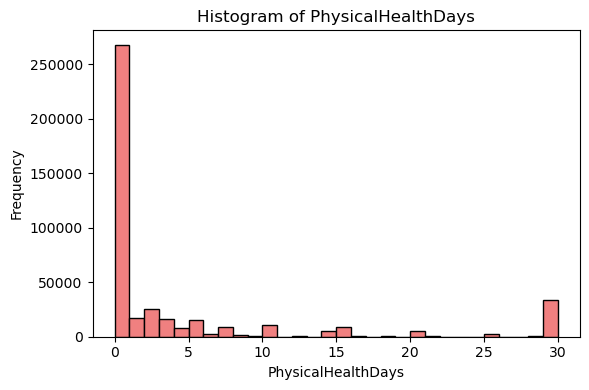

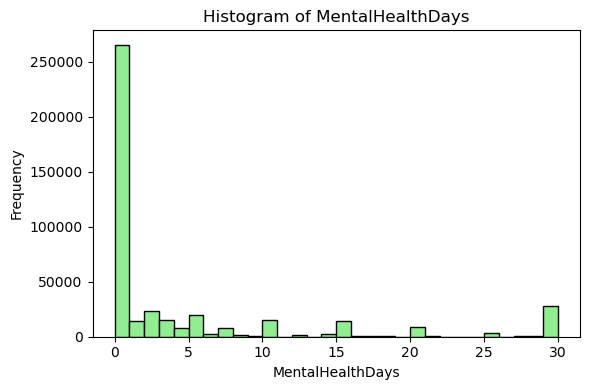

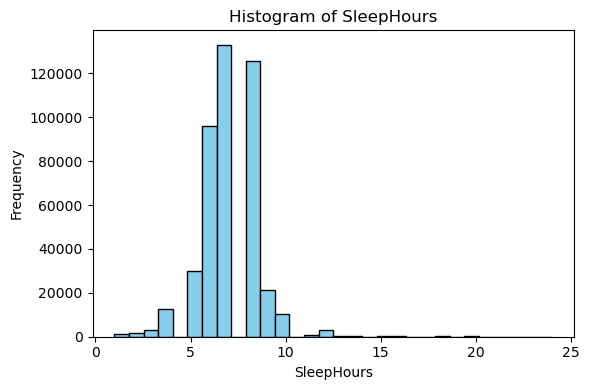

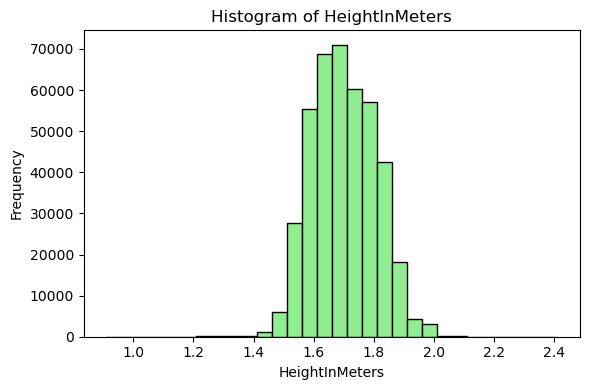

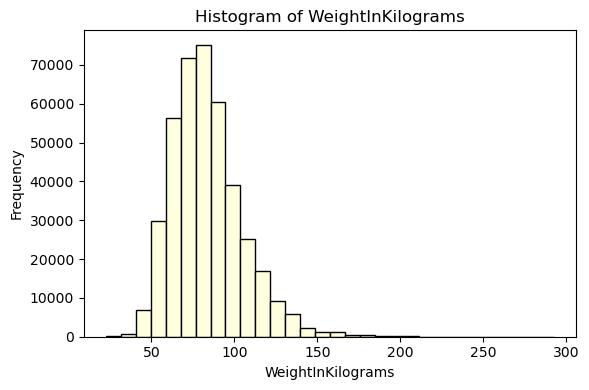

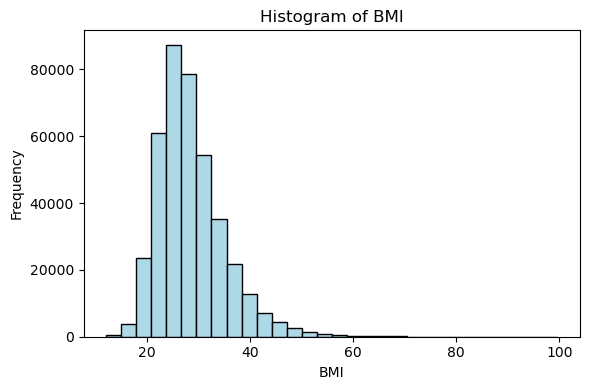

In [637]:
# Plot histogram for all numeric columns except "HadHeartAttack"
import random
import matplotlib.pyplot as plt

columns_to_plot = df.select_dtypes(exclude='object').columns

for col in columns_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30, color=colors[random.randint(0, len(colors) - 1)], edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")

    plt.tight_layout()
    plt.show()


#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers

In [638]:
# Create a copy of the original dataframe
df_original = df.copy()

In [639]:
# Keep this code commented and use it only if you want to revert back to original dataframe
# df = df_original.copy()

<span style="color: green; font-weight: bold; font-size:16px">Dropping duplicates</span>


In [640]:
# Remove duplicate records from df
print(f"Number of duplicate records before removing duplicates: {len(df)}")
df = df.drop_duplicates()
print(f"Number of duplicate records after removing duplicates: {len(df)}")


Number of duplicate records before removing duplicates: 445132
Number of duplicate records after removing duplicates: 444975


Dropping NULL data from target column __HadHeartAttack__

In [641]:
# Drop rows where HadHeartAttack is null

df = df.dropna(subset=['HadHeartAttack'])

print(df["HadHeartAttack"].value_counts(dropna=False))


HadHeartAttack
No     416807
Yes     25108
Name: count, dtype: int64


Transforming data for HadHeartAttach column to numeric value as 0 for No, and 1 for yes


In [642]:
print("Unique values in HadHeartAttack column:")
print(df['HadHeartAttack'].unique())
print("\nData type:", df['HadHeartAttack'].dtype)

# Map 'No' to 0 and 'Yes' to 1 in HadHeartAttack column
df['HadHeartAttack'] = df['HadHeartAttack'].map({'No': 0, 'Yes': 1})
print(df["HadHeartAttack"].value_counts(dropna=False))


Unique values in HadHeartAttack column:
['No' 'Yes']

Data type: object
HadHeartAttack
0    416807
1     25108
Name: count, dtype: int64


#### Train-Test Split (Before Preprocessing)

**Important:** Splitting data BEFORE preprocessing ensures:
1. No data leakage from test set to training set
2. Imputation statistics (median, mode) computed only from training data
3. Encoding mappings learned only from training data
4. More realistic model evaluation


In [643]:
from sklearn.model_selection import train_test_split

# Split data immediately after target variable transformation
# This prevents any preprocessing information from leaking from test to train

y = df[target_variable]
X = df.drop(columns=[target_variable])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 100)
print("TRAIN-TEST SPLIT COMPLETED BEFORE PREPROCESSING")
print("=" * 100)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())
print("=" * 100)


TRAIN-TEST SPLIT COMPLETED BEFORE PREPROCESSING
Training set: 353532 samples (80.0%)
Test set: 88383 samples (20.0%)

Class distribution in training set:
HadHeartAttack
0    333446
1     20086
Name: count, dtype: int64

Class distribution in test set:
HadHeartAttack
0    83361
1     5022
Name: count, dtype: int64


##### Handling Missing Values for Numeric columns

<span style="color: green; font-weight: bold; font-size:16px">PhysicalHealthDays and MentalHealthDays has highly skewed data, so imputing it using median value</span>



In [644]:
print(numeric_columns)

# Compute median from training data only and apply to both train and test
# This prevents data leakage from test set

median_values = {}
for col in numeric_columns:
    # Calculate median from training data only
    median_values[col] = X_train[col].median()
    # Apply to both train and test
    X_train[col] = X_train[col].fillna(median_values[col])
    X_test[col] = X_test[col].fillna(median_values[col])

print("\nMedian values used for imputation (computed from training data):")
for col, val in median_values.items():
    print(f"  {col}: {val:.2f}")

# Check for remaining NaNs
nan_percent_train = X_train[numeric_columns].isna().mean().mul(100).to_frame('Train NaN %')
nan_percent_test = X_test[numeric_columns].isna().mean().mul(100).to_frame('Test NaN %')
nan_comparison = pd.concat([nan_percent_train, nan_percent_test], axis=1)

print("\nRemaining NaN percentage after imputation:")
print(nan_comparison.sort_values(by='Train NaN %', ascending=False))


Index(['BMI', 'HeightInMeters', 'MentalHealthDays', 'PhysicalHealthDays',
       'SleepHours', 'WeightInKilograms'],
      dtype='object')

Median values used for imputation (computed from training data):
  BMI: 27.44
  HeightInMeters: 1.70
  MentalHealthDays: 0.00
  PhysicalHealthDays: 0.00
  SleepHours: 7.00
  WeightInKilograms: 80.74

Remaining NaN percentage after imputation:
                    Train NaN %  Test NaN %
BMI                         0.0         0.0
HeightInMeters              0.0         0.0
MentalHealthDays            0.0         0.0
PhysicalHealthDays          0.0         0.0
SleepHours                  0.0         0.0
WeightInKilograms           0.0         0.0


##### Handling Missing Values for Categorical columns

In [645]:
# Print unique values of object columns that are not boolean columns
non_boolean_object_columns = [col for col in object_columns if col not in boolean_columns]

print(non_boolean_object_columns)
print("\nNote: Examining training data to determine encoding strategy")
print("=" * 100)

for col in non_boolean_object_columns:
    print(f"\nUnique values for column '{col}' in TRAINING data:")
    print(X_train[col].unique())
    print("-" * 100)



['AgeCategory', 'CovidPos', 'ECigaretteUsage', 'GeneralHealth', 'HadDiabetes', 'HadHeartAttack', 'LastCheckupTime', 'RaceEthnicityCategory', 'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap']

Note: Examining training data to determine encoding strategy

Unique values for column 'AgeCategory' in TRAINING data:
['Age 35 to 39' 'Age 45 to 49' 'Age 65 to 69' 'Age 30 to 34'
 'Age 70 to 74' 'Age 18 to 24' 'Age 60 to 64' 'Age 55 to 59'
 'Age 80 or older' 'Age 75 to 79' 'Age 50 to 54' 'Age 40 to 44'
 'Age 25 to 29' nan]
----------------------------------------------------------------------------------------------------

Unique values for column 'CovidPos' in TRAINING data:
['No' nan 'Yes'
 'Tested positive using home test without a health professional']
----------------------------------------------------------------------------------------------------

Unique values for column 'ECigaretteUsage' in TRAINING data:
['Not at all (right now)' 'Use them every day'
 'Never used e-

KeyError: 'HadHeartAttack'

__Creating Maps for categorical columns:__

'AgeCategory', 'AlcoholDrinkers', 'BlindOrVisionDifficulty',
'ChestScan', 'CovidPos', 'DeafOrHardOfHearing',
'DifficultyConcentrating', 'DifficultyDressingBathing',
'DifficultyErrands', 'DifficultyWalking', 'ECigaretteUsage',
'FluVaxLast12', 'GeneralHealth', 'HIVTesting', 'HadAngina',
'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder',
'HadDiabetes', 'HadHeartAttack', 'HadKidneyDisease', 'HadSkinCancer',
'HadStroke', 'HighRiskLastYear', 'LastCheckupTime',
'PhysicalActivities', 'PneumoVaxEver', 'RaceEthnicityCategory',
'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap'

<u>__AgeCategory__</u>

In [ ]:

columnName = "AgeCategory"

print("Training data distribution:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Drop rows with missing AgeCategory from both train and test
rows_before_train = len(X_train)
rows_before_test = len(X_test)
X_train = X_train.dropna(subset=[columnName])
X_test = X_test.dropna(subset=[columnName])
y_train = y_train[X_train.index]
y_test = y_test[X_test.index]

print(f"\nDropped {rows_before_train - len(X_train)} rows from training set")
print(f"Dropped {rows_before_test - len(X_test)} rows from test set")

# Define ordinal mapping based on age categories
columns_map = {
    'Age 18 to 24': 1, 
    'Age 25 to 29': 2, 
    'Age 30 to 34': 3, 
    'Age 35 to 39': 4, 
    'Age 40 to 44': 5, 
    'Age 45 to 49': 6, 
    'Age 50 to 54': 7, 
    'Age 55 to 59': 8, 
    'Age 60 to 64': 9, 
    'Age 65 to 69': 10, 
    'Age 70 to 74': 11, 
    'Age 75 to 79': 12, 
    'Age 80 or older': 13
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)
print(f"{columnName} Column exists: {columnName in X_train.columns}")




AgeCategory
NaN                 8802
Age 25 to 29       21901
Age 30 to 34       25687
Age 18 to 24       26792
Age 35 to 39       28371
Age 45 to 49       28392
Age 40 to 44       29778
Age 75 to 79       32231
Age 50 to 54       33436
Age 80 or older    35736
Age 55 to 59       36611
Age 70 to 74       43194
Age 60 to 64       44191
Age 65 to 69       46793
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack       0     1
AgeCategory                 
Age 18 to 24     26670   122
Age 25 to 29     21782   119
Age 30 to 34     25500   187
Age 35 to 39     28053   318
Age 40 to 44     29333   445
Age 45 to 49     27664   728
Age 50 to 54     32186  1250
Age 55 to 59     34651  1960
Age 60 to 64     41301  2890
Age 65 to 69     43093  3700
Age 70 to 74     38978  4216
Age 75 to 79     28442  3789
Age 80 or older  30712  5024
NaN               8442   360
-----------------------------------------------

CovidPos

['No' 'Yes' nan 'Tested positive using home test without a health professional']

In [ ]:
columnName = "CovidPos"

print("Training data distribution:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Fill missing values with 'Unknown'
X_train[columnName] = X_train[columnName].fillna('Unknown')
X_test[columnName] = X_test[columnName].fillna('Unknown')

columns_map = {
    'No': 0,
    'Yes': 1,
    'Tested positive using home test without a health professional': 2,
    'Unknown': -1
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)
print(f"{columnName} Column exists: {columnName in X_train.columns}")




CovidPos
Tested positive using home test without a health professional     13242
NaN                                                               47561
Yes                                                              108773
No                                                               263537
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack                                           0      1
CovidPos                                                         
No                                                  247345  16192
Tested positive using home test without a healt...   12850    392
Yes                                                 103270   5503
NaN                                                  44900   2661
----------------------------------------------------------------------------------------------------
CovidPos
 2     13242
-1     47561
 1    108773
 0    263537
Name: count, dtype

ECigaretteUsage

['Not at all (right now)' 'Never used e-cigarettes in my entire life' nan
 'Use them every day' 'Use them some days']

<span style="color: green; font-weight: bold; font-size:16px">Note: combining 'Not at all (right now)' and 'Never used e-cigarettes in my entire life' as 0</span>

In [ ]:
columnName = "ECigaretteUsage"

print("Training data distribution:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Fill missing values with 'Unknown'
X_train[columnName] = X_train[columnName].fillna('Unknown')
X_test[columnName] = X_test[columnName].fillna('Unknown')

# combining 'Not at all (right now)' and 'Never used e-cigarettes in my entire life' as 0
columns_map = {
    'Not at all (right now)': 0,
    'Never used e-cigarettes in my entire life': 0,
    'Use them every day': 1,
    'Use them some days': 2,
    'Unknown': -1
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

ECigaretteUsage
Use them every day                            10235
Use them some days                            11529
NaN                                           33101
Not at all (right now)                        73743
Never used e-cigarettes in my entire life    304505
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack                                  0      1
ECigaretteUsage                                         
Never used e-cigarettes in my entire life  286710  17795
Not at all (right now)                      69464   4279
Use them every day                           9916    319
Use them some days                          11077    452
NaN                                         31198   1903
----------------------------------------------------------------------------------------------------
ECigaretteUsage
 1     10235
 2     11529
-1     33101
 0    378248
Name: count, dtype: int64
---

GeneralHealth

['Very good' 'Excellent' 'Fair' 'Poor' 'Good' nan]

In [ ]:
columnName = "GeneralHealth"

print("Training data distribution:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Drop rows with missing GeneralHealth from both train and test
rows_before_train = len(X_train)
rows_before_test = len(X_test)
X_train = X_train.dropna(subset=[columnName])
X_test = X_test.dropna(subset=[columnName])
y_train = y_train[X_train.index]
y_test = y_test[X_test.index]

print(f"\nDropped {rows_before_train - len(X_train)} rows from training set")
print(f"Dropped {rows_before_test - len(X_test)} rows from test set")

# Ordinal encoding for health status
columns_map = {
    'Excellent': 5,
    'Very good': 4,
    'Good': 3,
    'Fair': 2,
    'Poor': 1,
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

GeneralHealth
NaN            1030
Poor          19023
Fair          58523
Excellent     69906
Good         139596
Very good    145035
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack       0     1
GeneralHealth               
Excellent        68830  1076
Fair             51385  7138
Good            131429  8167
Poor             14906  4117
Very good       140896  4139
NaN                919   111
----------------------------------------------------------------------------------------------------
GeneralHealth
1     19023
2     58523
5     69906
3    139596
4    145035
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


HadDiabetes

['Yes' 'No' 'No, pre-diabetes or borderline diabetes' nan
 'Yes, but only during pregnancy (female)']

In [ ]:
columnName = "HadDiabetes"

print("Training data distribution:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Drop rows with missing HadDiabetes from both train and test
rows_before_train = len(X_train)
rows_before_test = len(X_test)
X_train = X_train.dropna(subset=[columnName])
X_test = X_test.dropna(subset=[columnName])
y_train = y_train[X_train.index]
y_test = y_test[X_test.index]

print(f"\nDropped {rows_before_train - len(X_train)} rows from training set")
print(f"Dropped {rows_before_test - len(X_test)} rows from test set")

columns_map = {
   'Yes, but only during pregnancy (female)': 1,  # Lowest risk (2.91%)
   'No': 2,                                        # Low risk (4.24%)
   'No, pre-diabetes or borderline diabetes': 3,  # Medium risk (7.70%)
   'Yes': 4,  
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

HadDiabetes
NaN                                           735
Yes, but only during pregnancy (female)      3748
No, pre-diabetes or borderline diabetes     10050
Yes                                         59278
No                                         358272
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack                                0      1
HadDiabetes                                           
No                                       343093  15179
No, pre-diabetes or borderline diabetes    9276    774
Yes                                       50779   8499
Yes, but only during pregnancy (female)    3639    109
NaN                                         659     76
----------------------------------------------------------------------------------------------------
HadDiabetes
1      3748
3     10050
4     59278
2    358272
Name: count, dtype: int64
---------------------------------------

LastCheckupTime

['Within past year (anytime less than 12 months ago)' nan
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within past 5 years (2 years but less than 5 years ago)'
 '5 or more years ago']

In [ ]:
columnName = "LastCheckupTime"

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Fill missing values with 'Unknown'
X_train[columnName] = X_train[columnName].fillna('Unknown')
X_test[columnName] = X_test[columnName].fillna('Unknown')

columns_map = {
   'Within past year (anytime less than 12 months ago)': 1,
   'Within past 2 years (1 year but less than 2 years ago)': 2,
   'Within past 5 years (2 years but less than 5 years ago)': 3,
   '5 or more years ago': 4,
   'Unknown': -1
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)  



HadHeartAttack                                           0      1
LastCheckupTime                                                  
5 or more years ago                                  18057    410
Within past 2 years (1 year but less than 2 yea...   39629   1118
Within past 5 years (2 years but less than 5 ye...   23712    509
Within past year (anytime less than 12 months ago)  318204  22216
NaN                                                   7185    308
----------------------------------------------------------------------------------------------------
LastCheckupTime
-1      7493
 4     18467
 3     24221
 2     40747
 1    340420
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


RemovedTeeth

[nan 'None of them' '1 to 5' '6 or more, but not all' 'All']

In [ ]:
columnName = "RemovedTeeth"

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Fill missing values with 'Unknown'
X_train[columnName] = X_train[columnName].fillna('Unknown')
X_test[columnName] = X_test[columnName].fillna('Unknown')

columns_map = {
  'None of them': 0,
  '1 to 5': 1,
  '6 or more, but not all': 2,
  'All': 3,
  'Unknown': -1
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)
print(f"{columnName} Column exists: {columnName in X_train.columns}")

print("*" * 100)

HadHeartAttack               0     1
RemovedTeeth                        
1 to 5                  118017  7560
6 or more, but not all   38947  5332
All                      20291  4278
None of them            220304  6413
NaN                       9228   978
----------------------------------------------------------------------------------------------------
RemovedTeeth
-1     10206
 3     24569
 2     44279
 1    125577
 0    226717
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
RemovedTeeth Column exists: True
****************************************************************************************************


TetanusLast10Tdap

['Yes, received tetanus shot but not sure what type'
 'No, did not receive any tetanus shot in the past 10 years' nan
 'Yes, received Tdap' 'Yes, received tetanus shot, but not Tdap']

In [ ]:
columnName = "TetanusLast10Tdap"

# Analyze relationship with target in training data only
train_with_target = X_train.copy()
train_with_target['HadHeartAttack'] = y_train
grouped = train_with_target.groupby([columnName, 'HadHeartAttack'], dropna=False)
print("\nRelationship with target (training data only):")
print(grouped.size().unstack())
print("-" * 100)

# Fill missing values with 'Unknown'
X_train[columnName] = X_train[columnName].fillna('Unknown')
X_test[columnName] = X_test[columnName].fillna('Unknown')

# combining 'Yes, received tetanus shot but not sure what type', 'Yes, received tetanus shot, but not Tdap' and 'Yes, received Tdap' as 1
# combining 'No, did not receive any tetanus shot in the past 10 years' as 0

columns_map = {
  'Yes, received tetanus shot but not sure what type': 1,
  'No, did not receive any tetanus shot in the past 10 years': 0,
  'Yes, received Tdap': 1,
  'Yes, received tetanus shot, but not Tdap': 1,
  'Unknown': -1
}

# Apply mapping to both train and test
X_train[columnName] = X_train[columnName].map(columns_map)
X_test[columnName] = X_test[columnName].map(columns_map)

print("\nAfter encoding:")
print(X_train[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)
print(f"{columnName} Column exists: {columnName in X_train.columns}")

print("*" * 100)

HadHeartAttack                                           0     1
TetanusLast10Tdap                                               
No, did not receive any tetanus shot in the pas...  110699  7418
Yes, received Tdap                                   93972  3974
Yes, received tetanus shot but not sure what type   103488  7116
Yes, received tetanus shot, but not Tdap             25006  1787
NaN                                                  73622  4266
----------------------------------------------------------------------------------------------------
TetanusLast10Tdap
-1     77888
 0    118117
 1    235343
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
TetanusLast10Tdap Column exists: True
****************************************************************************************************


#### Null Handling for Boolean (Yes, No, NaN) columns

['AlcoholDrinkers', 'BlindOrVisionDifficulty', 'ChestScan', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'DifficultyDressingBathing', 'DifficultyErrands', 'DifficultyWalking', 'FluVaxLast12', 'HIVTesting', 'HadAngina', 'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadSkinCancer', 'HadStroke', 'HighRiskLastYear', 'PhysicalActivities', 'PneumoVaxEver']

In [ ]:
print("*" * 100)

# Process boolean columns for both train and test sets
for column in boolean_columns:
    # Fill missing values with 'Unknown'
    X_train[column] = X_train[column].fillna('Unknown')
    X_test[column] = X_test[column].fillna('Unknown')
    
    # Apply mapping to both train and test
    X_train[column] = X_train[column].map({'Yes': 1, 'No': 0, 'Unknown': -1})
    X_test[column] = X_test[column].map({'Yes': 1, 'No': 0, 'Unknown': -1})
    
    print(f"{column} - Training set distribution:")
    print(X_train[column].value_counts(dropna=False, ascending=True))
    print("-" * 100)


****************************************************************************************************
AlcoholDrinkers
-1     43119
 0    181725
 1    206504
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
BlindOrVisionDifficulty
-1     19727
 1     22746
 0    388875
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
ChestScan
-1     52324
 1    161224
 0    217800
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
DeafOrHardOfHearing
-1     18862
 1     37606
 0    374880
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
DifficultyConcentrating
-1     22188
 1     48513
 0    360647
Name: count, dtype: int64
----------------------------------------------------------------------------

#### Data verification after Null Handling and Data transformation 

In [ ]:
# Percentage of null values in each column for train and test sets
nan_percent_train = X_train.isna().mean().mul(100).to_frame('Train NaN %')
nan_percent_test = X_test.isna().mean().mul(100).to_frame('Test NaN %')
nan_comparison = pd.concat([nan_percent_train, nan_percent_test], axis=1)

print("Remaining NaN percentages after preprocessing:")
nan_comparison.sort_values(by='Train NaN %', ascending=False)

,NaN %
SmokerStatus,7.565817
RaceEthnicityCategory,2.689708
State,0.000000
Sex,0.000000
DifficultyWalking,0.000000
DifficultyDressingBathing,0.000000
DifficultyErrands,0.000000
ECigaretteUsage,0.000000
ChestScan,0.000000
AgeCategory,0.000000


In [ ]:
allColumns = X_train.columns.sort_values()

print("TRAINING SET - Value counts for all columns:")
print("=" * 100)
for column in allColumns:
    print(f"\n{column}")
    print(X_train[column].value_counts(dropna=False, ascending=True))
    print("-" * 100)



AgeCategory
AgeCategory
2     21822
3     25587
1     26668
4     28281
6     28289
5     29682
12    32088
7     33309
13    35489
8     36487
11    43031
9     44013
10    46602
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
AlcoholDrinkers
AlcoholDrinkers
-1     43119
 0    181725
 1    206504
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
BMI
BMI
48.63        1
31.76        1
65.80        1
40.22        1
43.67        1
         ...  
27.12     3013
24.41     3104
27.46     3218
26.63     4170
27.44    46464
Name: count, Length: 3959, dtype: int64
----------------------------------------------------------------------------------------------------
BlindOrVisionDifficulty
BlindOrVisionDifficulty
-1     19727
 1     22746
 0    388875
Name: count, dtype: int64
--------------------------------------------------------------------

#### Encoding Nominal Categorical Features


In [ ]:
object_columns = X_train.select_dtypes(include='object').columns.tolist()
print("Object columns (nominal categorical - need one-hot encoding):", object_columns)
print("-" * 100)

numeric_columns = X_train.select_dtypes(exclude=['object']).columns.tolist()
print("Numeric columns (already encoded or continuous):", numeric_columns)


Object columns: []
----------------------------------------
Numeric columns: ['GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'ECigaretteUsage', 'ChestScan', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos', 'Sex_Female', 'Sex_Male', 'State_Alabama', 'State_Alaska', 'State_Arizona', 'State_Arkansas', 'State_California', 'State_Colorado', 'State_Connecticut', 'State_Delaware', 'State_District of Columbia', 'State_Florida', 'State_Georgia', 'State_Guam', 'State_Hawaii', 'State

<u>__1. Sex__</u>

In [ ]:
# One-hot encode the 'Sex' column
# Fit on training data and apply to both train and test
sex_dummies_train = pd.get_dummies(X_train['Sex'], prefix='Sex')
sex_dummies_test = pd.get_dummies(X_test['Sex'], prefix='Sex')

# Ensure both train and test have the same columns
all_sex_cols = list(set(sex_dummies_train.columns) | set(sex_dummies_test.columns))
for col in all_sex_cols:
    if col not in sex_dummies_train.columns:
        sex_dummies_train[col] = 0
    if col not in sex_dummies_test.columns:
        sex_dummies_test[col] = 0

# Sort columns to ensure same order
sex_dummies_train = sex_dummies_train[sorted(sex_dummies_train.columns)]
sex_dummies_test = sex_dummies_test[sorted(sex_dummies_test.columns)]

# Add encoded columns to train and test, drop original
X_train = pd.concat([X_train.drop('Sex', axis=1), sex_dummies_train], axis=1)
X_test = pd.concat([X_test.drop('Sex', axis=1), sex_dummies_test], axis=1)

# Show the new columns created for 'Sex'
print("One-hot encoded columns for 'Sex':", sorted(all_sex_cols))
print("-" * 100)

One-hot encoded columns for 'Sex': ['Sex_Female', 'Sex_Male']
----------------------------------------------------------------------------------------------------


<u>__2. State__</u>

In [ ]:
# One-hot encode the 'State' column
# Fit on training data and apply to both train and test
state_dummies_train = pd.get_dummies(X_train['State'], prefix='State')
state_dummies_test = pd.get_dummies(X_test['State'], prefix='State')

# Ensure both train and test have the same columns
all_state_cols = list(set(state_dummies_train.columns) | set(state_dummies_test.columns))
for col in all_state_cols:
    if col not in state_dummies_train.columns:
        state_dummies_train[col] = 0
    if col not in state_dummies_test.columns:
        state_dummies_test[col] = 0

# Sort columns to ensure same order
state_dummies_train = state_dummies_train[sorted(state_dummies_train.columns)]
state_dummies_test = state_dummies_test[sorted(state_dummies_test.columns)]

# Add encoded columns to train and test, drop original
X_train = pd.concat([X_train.drop('State', axis=1), state_dummies_train], axis=1)
X_test = pd.concat([X_test.drop('State', axis=1), state_dummies_test], axis=1)

# Show the new columns created for 'State'
print("One-hot encoded columns for 'State':", sorted(all_state_cols))
print("-" * 100)


One-hot encoded columns for 'State': ['State_Alabama', 'State_Alaska', 'State_Arizona', 'State_Arkansas', 'State_California', 'State_Colorado', 'State_Connecticut', 'State_Delaware', 'State_District of Columbia', 'State_Florida', 'State_Georgia', 'State_Guam', 'State_Hawaii', 'State_Idaho', 'State_Illinois', 'State_Indiana', 'State_Iowa', 'State_Kansas', 'State_Kentucky', 'State_Louisiana', 'State_Maine', 'State_Maryland', 'State_Massachusetts', 'State_Michigan', 'State_Minnesota', 'State_Mississippi', 'State_Missouri', 'State_Montana', 'State_Nebraska', 'State_Nevada', 'State_New Hampshire', 'State_New Jersey', 'State_New Mexico', 'State_New York', 'State_North Carolina', 'State_North Dakota', 'State_Ohio', 'State_Oklahoma', 'State_Oregon', 'State_Pennsylvania', 'State_Puerto Rico', 'State_Rhode Island', 'State_South Carolina', 'State_South Dakota', 'State_Tennessee', 'State_Texas', 'State_Utah', 'State_Vermont', 'State_Virgin Islands', 'State_Virginia', 'State_Washington', 'State_Wes

<u>__3.  SmokerStatus__</u>

In [ ]:
# One-hot encode the 'SmokerStatus' column
# Fit on training data and apply to both train and test
smoker_status_dummies_train = pd.get_dummies(X_train['SmokerStatus'], prefix='SmokerStatus')
smoker_status_dummies_test = pd.get_dummies(X_test['SmokerStatus'], prefix='SmokerStatus')

# Ensure both train and test have the same columns
all_smoker_cols = list(set(smoker_status_dummies_train.columns) | set(smoker_status_dummies_test.columns))
for col in all_smoker_cols:
    if col not in smoker_status_dummies_train.columns:
        smoker_status_dummies_train[col] = 0
    if col not in smoker_status_dummies_test.columns:
        smoker_status_dummies_test[col] = 0

# Sort columns to ensure same order
smoker_status_dummies_train = smoker_status_dummies_train[sorted(smoker_status_dummies_train.columns)]
smoker_status_dummies_test = smoker_status_dummies_test[sorted(smoker_status_dummies_test.columns)]

# Add encoded columns to train and test, drop original
X_train = pd.concat([X_train.drop('SmokerStatus', axis=1), smoker_status_dummies_train], axis=1)
X_test = pd.concat([X_test.drop('SmokerStatus', axis=1), smoker_status_dummies_test], axis=1)

# Show the new columns created for 'SmokerStatus'
print("One-hot encoded columns for 'SmokerStatus':", sorted(all_smoker_cols))
print("-" * 100)

One-hot encoded columns for 'SmokerStatus': ['SmokerStatus_Current smoker - now smokes every day', 'SmokerStatus_Current smoker - now smokes some days', 'SmokerStatus_Former smoker', 'SmokerStatus_Never smoked']
----------------------------------------------------------------------------------------------------


<u>__4.  RaceEthnicityCategory__</u>

In [ ]:
# One-hot encode the 'RaceEthnicityCategory' column
# Fit on training data and apply to both train and test
race_ethnicity_dummies_train = pd.get_dummies(X_train['RaceEthnicityCategory'], prefix='RaceEthnicityCategory')
race_ethnicity_dummies_test = pd.get_dummies(X_test['RaceEthnicityCategory'], prefix='RaceEthnicityCategory')

# Ensure both train and test have the same columns
all_race_cols = list(set(race_ethnicity_dummies_train.columns) | set(race_ethnicity_dummies_test.columns))
for col in all_race_cols:
    if col not in race_ethnicity_dummies_train.columns:
        race_ethnicity_dummies_train[col] = 0
    if col not in race_ethnicity_dummies_test.columns:
        race_ethnicity_dummies_test[col] = 0

# Sort columns to ensure same order
race_ethnicity_dummies_train = race_ethnicity_dummies_train[sorted(race_ethnicity_dummies_train.columns)]
race_ethnicity_dummies_test = race_ethnicity_dummies_test[sorted(race_ethnicity_dummies_test.columns)]

# Add encoded columns to train and test, drop original
X_train = pd.concat([X_train.drop('RaceEthnicityCategory', axis=1), race_ethnicity_dummies_train], axis=1)
X_test = pd.concat([X_test.drop('RaceEthnicityCategory', axis=1), race_ethnicity_dummies_test], axis=1)

# Show the new columns created for 'RaceEthnicityCategory'
print("One-hot encoded columns for 'RaceEthnicityCategory':", sorted(all_race_cols))
print("-" * 100)

One-hot encoded columns for 'RaceEthnicityCategory': ['RaceEthnicityCategory_Black only, Non-Hispanic', 'RaceEthnicityCategory_Hispanic', 'RaceEthnicityCategory_Multiracial, Non-Hispanic', 'RaceEthnicityCategory_Other race only, Non-Hispanic', 'RaceEthnicityCategory_White only, Non-Hispanic']
----------------------------------------------------------------------------------------------------


### Bivariate Analysis

In [ ]:
print(numeric_columns)
print("-" * 100)
print(object_columns)


['GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'ECigaretteUsage', 'ChestScan', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']
----------------------------------------------------------------------------------------------------
['State', 'Sex', 'SmokerStatus', 'RaceEthnicityCategory']


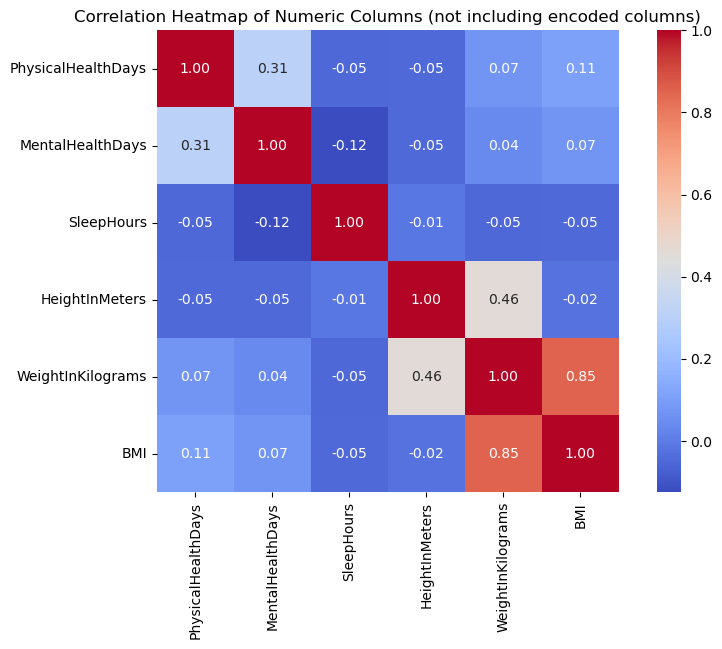

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use original continuous numeric columns for correlation analysis
original_numeric_columns = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI'] 

# Compute the correlation matrix from TRAINING data only
corr_matrix = X_train[original_numeric_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Columns - Training Data Only")
plt.show()



### Feature Selection


##### This cell demonstrates why scaling is important by comparing variances
##### Note: Actual scaling will be applied after train-test split and SMOTE

In [ ]:
# This cell demonstrates why scaling is important by comparing variances
# Note: Actual scaling will be applied with SMOTE using Pipelines

# Get numeric columns from training data
train_numeric_columns = X_train.select_dtypes(exclude='object').columns.tolist()

# Calculate variance from training data before scaling
variances_before_scaling = X_train[train_numeric_columns].var()

# Demonstrate what scaling does to the variance (fit on training data only)
scaler_demo = StandardScaler()
scaled_data_demo = scaler_demo.fit_transform(X_train[train_numeric_columns])
scaled_df_demo = pd.DataFrame(scaled_data_demo, columns=train_numeric_columns)
variances_after = scaled_df_demo.var()

variances_comparison = pd.DataFrame({
    'Variance Before Scaling': variances_before_scaling,
    'Variance After Scaling': variances_after
})
print("Comparison of variances before and after scaling (Training Data):")
print(variances_comparison)
print("\nNote: Standardization brings all features to similar scale (variance ≈ 1)")
print("This demonstration uses only training data to prevent any data leakage.")

Comparison of variances before and after scaling:
                           Variance Before Scaling  Variance After Scaling
GeneralHealth                             1.103972                1.000002
PhysicalHealthDays                       73.713950                1.000002
MentalHealthDays                         69.109645                1.000002
LastCheckupTime                           0.683591                1.000002
PhysicalActivities                        0.187795                1.000002
SleepHours                                2.208616                1.000002
RemovedTeeth                              0.823746                1.000002
HadHeartAttack                            0.053698                1.000002
HadAngina                                 0.064684                1.000002
HadStroke                                 0.043541                1.000002
HadAsthma                                 0.131590                1.000002
HadSkinCancer                             0.080568

#### Note: Train-Test Split Already Completed

**The train-test split was performed earlier in Cell 42 (immediately after target variable transformation and before any preprocessing).** This ensures:
- No data leakage from test to training set
- All preprocessing (imputation, encoding, scaling) is fit on training data only
- More realistic model evaluation

In [ ]:
# Verify train-test split shapes after all preprocessing
print("=" * 100)
print("FINAL PREPROCESSED DATA SHAPES")
print("=" * 100)
print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"Total features after one-hot encoding: {X_train.shape[1]}")
print("=" * 100)

Train shape: (345078, 100) (345078,)
Test shape: (86270, 100) (86270,)


### A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [ ]:
# The baseline is the accuracy we'd get by always predicting the most frequent class.
# Find the most frequent class in the training set
most_frequent_class = y_train.value_counts().idxmax()
print(f"Most frequent class: {most_frequent_class}")
baseline_accuracy = (y_test == most_frequent_class).mean()

print(f"Baseline accuracy (majority class '{most_frequent_class}'): {baseline_accuracy:.4f}")

Most frequent class: 0
Baseline accuracy (majority class '0'): 0.9431


## Using Classification models 

### 1: A Simple Model

Use Logistic Regression to build a basic model on data.  

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instantiate the logistic regression model
logreg = LogisticRegression(max_iter=1000, solver='saga')

# Other solvers available for LogisticRegression include:
# - 'liblinear': Good for small datasets and supports L1 regularization.
# - 'newton-cg': Handles multinomial loss; good for multiclass problems.
# - 'sag': Stochastic Average Gradient, efficient for large datasets.
# - 'saga': Similar to 'sag', but also supports L1 regularization and multiclass.
# - 'lbfgs': Default for many cases, works well for multiclass and large datasets.


# Fit the model on the training data
logreg.fit(X_train, y_train)

# Predict on the test set
y_pred = logreg.predict(X_test)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression Test Accuracy: 0.9465

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     81358
           1       0.59      0.20      0.30      4912

    accuracy                           0.95     86270
   macro avg       0.77      0.60      0.64     86270
weighted avg       0.93      0.95      0.93     86270


Confusion Matrix:
[[80666   692]
 [ 3927   985]]


In [ ]:
# List of models to compare
models = [
    ("Logistic Regression", LogisticRegression(max_iter=5000, random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    # ("SVM", SVC(random_state=42)),
]

### Address class imbalance using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

# Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())


Class distribution before SMOTE:
HadHeartAttack
0    325429
1     19649
Name: count, dtype: int64

Class distribution after SMOTE:
HadHeartAttack
0    325429
1    325429
Name: count, dtype: int64


### Apply Feature Scaling using StandardScaler

<span style="color: green; font-weight: bold; font-size:16px">Scaling is critical for distance-based models (KNN) and regularized models (Logistic Regression). We fit the scaler on the training data and transform both train and test sets to prevent data leakage.</span>


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the SMOTE-balanced training data and transform it
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling completed!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Verify scaling by checking mean and std of a few features
print("\nSample statistics after scaling (should be ~0 mean, ~1 std for training data):")
print(X_train_scaled[['PhysicalHealthDays', 'BMI', 'AgeCategory']].describe())

print("\nNote: While we create scaled datasets here for reference,")
print("subsequent model comparisons use Pipeline which handles scaling internally.")


Scaling completed!
X_train_scaled shape: (650858, 100)
X_test_scaled shape: (86270, 100)

Sample statistics after scaling (should be ~0 mean, ~1 std for training data):
       PhysicalHealthDays           BMI   AgeCategory
count        6.508580e+05  6.508580e+05  6.508580e+05
mean        -1.227946e-16 -2.438599e-15  7.895186e-17
std          1.000001e+00  1.000001e+00  1.000001e+00
min         -6.093895e-01 -2.682928e+00 -2.360071e+00
25%         -6.093895e-01 -6.210675e-01 -5.257449e-01
50%         -6.093895e-01 -2.125404e-01  8.569712e-02
75%          1.225548e-01  4.539195e-01  6.971391e-01
max          2.227965e+00  1.130632e+01  1.308581e+00

Note: While we create scaled datasets here for reference,
subsequent model comparisons use Pipeline which handles scaling internally.


### Step 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

#### Using sklearn Pipeline for Model Training

**Benefits of Pipeline:**
1. **Encapsulation**: Combines preprocessing (scaling) and model training into a single object
2. **Prevents Data Leakage**: Ensures scaler is fit only on training data, then applied to test data
3. **Cleaner Code**: No need to manually track scaled datasets
4. **Production-Ready**: Easy to serialize and deploy the entire workflow
5. **GridSearchCV Compatible**: Seamlessly works with hyperparameter tuning
6. **Reproducibility**: Guarantees consistent preprocessing across train/test/new data

In [ ]:
import time
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipelines that combine scaling and model training
# This ensures proper sequencing and prevents data leakage
pipelines = [
    ("Logistic Regression", Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=5000, random_state=42))
    ])),
    ("KNN", Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier())
    ])),
    ("Decision Tree", Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])),
    # Note: Decision Trees don't need scaling, but included for consistency
]

results = []

for name, pipeline in pipelines:
    start_time = time.time()
    # Pipeline handles scaling internally during fit
    pipeline.fit(X_train_smote, y_train_smote)
    train_time = time.time() - start_time

    # Pipeline automatically applies scaling during score
    train_acc = pipeline.score(X_train_smote, y_train_smote)
    test_acc = pipeline.score(X_test, y_test)

    results.append({
        "Model": name,
        "Train Time": f"{train_time:.3f} s",
        "Train Accuracy": f"{train_acc:.4f}",
        "Test Accuracy": f"{test_acc:.4f}"
    })

results_df = pd.DataFrame(results)
print("\nModel Comparison Results (using Pipeline):")
print(results_df)



Model Comparison Results (using Pipeline):
                 Model Train Time Train Accuracy Test Accuracy
0  Logistic Regression    1.919 s         0.9626        0.9448
1                  KNN    0.783 s         0.9751        0.9309
2        Decision Tree    9.039 s         1.0000        0.8937


In [ ]:
from sklearn.metrics import confusion_matrix

for name, pipeline in pipelines:
    print(f"Confusion Matrix for {name}:")
    # Pipeline automatically applies scaling during predict
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print()


Confusion Matrix for Logistic Regression:
[[80294  1064]
 [ 3694  1218]]

Confusion Matrix for KNN:
[[79717  1641]
 [ 4321   591]]

Confusion Matrix for Decision Tree:
[[75425  5933]
 [ 3237  1675]]



In [ ]:
from sklearn.metrics import classification_report

for name, pipeline in pipelines:
    print(f"Classification Report for {name}:")
    # Pipeline automatically applies scaling during predict
    y_pred = pipeline.predict(X_test)
    print(classification_report(y_test, y_pred))
    print()


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     81358
           1       0.53      0.25      0.34      4912

    accuracy                           0.94     86270
   macro avg       0.74      0.62      0.65     86270
weighted avg       0.93      0.94      0.94     86270


Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     81358
           1       0.26      0.12      0.17      4912

    accuracy                           0.93     86270
   macro avg       0.61      0.55      0.56     86270
weighted avg       0.91      0.93      0.92     86270


Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94     81358
           1       0.22      0.34      0.27      4912

    accuracy                           0.89     86270
   macr

### Implement ensemble method - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create Random Forest Pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1, 
        class_weight='balanced'
    ))
])

# Fit the pipeline on the SMOTE-balanced training data
import time
start_time = time.time()
rf_pipeline.fit(X_train_smote, y_train_smote)
train_time = time.time() - start_time

# Evaluate accuracy (pipeline handles scaling automatically)
rf_train_acc = rf_pipeline.score(X_train_smote, y_train_smote)
rf_test_acc = rf_pipeline.score(X_test, y_test)

print("Random Forest Pipeline Results:")
print(f"Train Time: {train_time:.3f} s")
print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred_rf = rf_pipeline.predict(X_test)
print("\nConfusion Matrix for Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print()

print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))


Random Forest Pipeline Results:
Train Time: 8.415 s
Train Accuracy: 1.0000
Test Accuracy: 0.9369

Confusion Matrix for Random Forest:
[[79371  1987]
 [ 3459  1453]]

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     81358
           1       0.42      0.30      0.35      4912

    accuracy                           0.94     86270
   macro avg       0.69      0.64      0.66     86270
weighted avg       0.93      0.94      0.93     86270



#### Use cross-validation for more robust model evaluation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use StratifiedKFold to preserve class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate cross-validated accuracy using pipeline
# Pipeline handles scaling internally for each CV fold
rf_cv_scores = cross_val_score(
    rf_pipeline, X_train_smote, y_train_smote, 
    cv=cv, scoring='accuracy', n_jobs=-1
)

print("Random Forest Pipeline Cross-Validation Accuracy Scores:", rf_cv_scores)
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

# For more detailed metrics (precision, recall, f1), use cross_val_score with different scoring
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

rf_cv_precision = cross_val_score(
    rf_pipeline, X_train_smote, y_train_smote, 
    cv=cv, scoring='precision', n_jobs=-1
)
rf_cv_recall = cross_val_score(
    rf_pipeline, X_train_smote, y_train_smote, 
    cv=cv, scoring='recall', n_jobs=-1
)
rf_cv_f1 = cross_val_score(
    rf_pipeline, X_train_smote, y_train_smote, 
    cv=cv, scoring='f1', n_jobs=-1
)

print(f"Mean CV Precision: {rf_cv_precision.mean():.4f} ± {rf_cv_precision.std():.4f}")
print(f"Mean CV Recall:    {rf_cv_recall.mean():.4f} ± {rf_cv_recall.std():.4f}")
print(f"Mean CV F1-score:  {rf_cv_f1.mean():.4f} ± {rf_cv_f1.std():.4f}")

print("\nNote: Pipeline ensures each CV fold scales independently, preventing data leakage across folds.")


Random Forest Pipeline Cross-Validation Accuracy Scores: [0.9668285  0.96664413 0.96715884 0.96722004 0.96784998]
Mean CV Accuracy: 0.9671 ± 0.0004
Mean CV Precision: 0.9713 ± 0.0007
Mean CV Recall:    0.9627 ± 0.0002
Mean CV F1-score:  0.9670 ± 0.0004

Note: Pipeline ensures each CV fold scales independently, preventing data leakage across folds.


#### Analyze Random Forest feature importance to identify top predictors

Top 20 Random Forest Feature Importances (from Pipeline):
                                              Feature  Importance
0                                       GeneralHealth    0.104691
24                                        AgeCategory    0.074497
7                                           HadAngina    0.058012
5                                          SleepHours    0.043385
93                         SmokerStatus_Former smoker    0.041541
28                                    AlcoholDrinkers    0.040064
25                                     HeightInMeters    0.035404
26                                  WeightInKilograms    0.030645
99     RaceEthnicityCategory_White only, Non-Hispanic    0.029993
27                                                BMI    0.029545
36                                           Sex_Male    0.029068
94                          SmokerStatus_Never smoked    0.028869
4                                  PhysicalActivities    0.028138
1                 

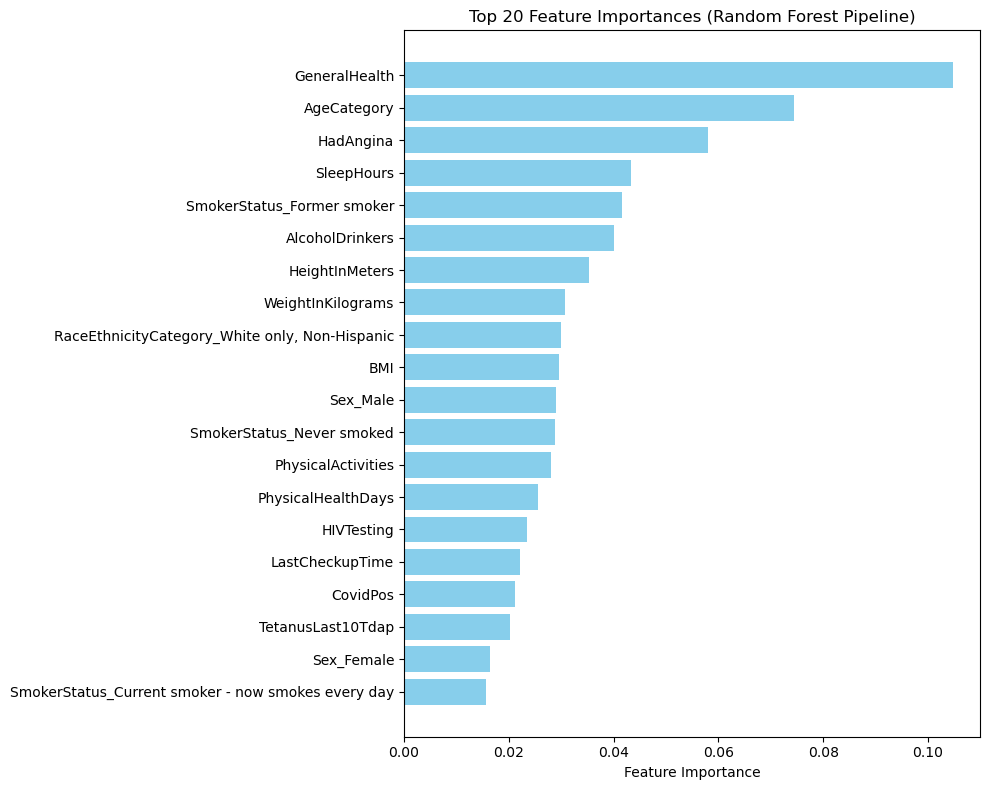

In [ ]:
# Analyze Random Forest feature importance to identify top predictors

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained Random Forest classifier in the pipeline
# Access the classifier step using named_steps
rf_classifier = rf_pipeline.named_steps['classifier']
importances = rf_classifier.feature_importances_

# Use feature names from X_train (unscaled data has same column names)
feature_names = X_train.columns

# Create a DataFrame for easy sorting and visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance descending
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Display top 20 features
print("Top 20 Random Forest Feature Importances (from Pipeline):")
print(feat_imp_df.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'].head(20)[::-1], feat_imp_df['Importance'].head(20)[::-1], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances (Random Forest Pipeline)')
plt.tight_layout()
plt.show()


#### Hyperparameter Optimization : Perform GridSearchCV on Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline for GridSearchCV
rf_pipeline_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define the parameter grid for Random Forest
# Note: Use 'classifier__' prefix for classifier parameters in pipeline
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

# Set up GridSearchCV with pipeline
grid_search = GridSearchCV(
    estimator=rf_pipeline_grid,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV on the SMOTE-balanced training data
# Pipeline handles scaling internally for each CV fold
grid_search.fit(X_train_smote, y_train_smote)

# Print the best parameters and best score
print("\nBest parameters found by GridSearchCV (Pipeline):")
print(grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

# Get the best estimator (entire pipeline)
best_rf_pipeline = grid_search.best_estimator_

print("\nNote: GridSearchCV with Pipeline ensures proper scaling within each CV fold.")
print("This prevents data leakage and provides more reliable hyperparameter selection.")


Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time= 1.3min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=2, classifier__n_estimators=100; total time= 1.4min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 1.4min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time= 1.5min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 1.5min
[CV] END classifier__max_dep

#### Training RandomForestClassifier using Best Parameters found above

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Option 1: Use the best pipeline from GridSearchCV
# best_rf_final = best_rf_pipeline

# Option 2: Create a new pipeline with best parameters and class_weight
rf_best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1, 
        class_weight='balanced'  # Added for handling imbalance
    ))
])

# Fit the pipeline on the SMOTE-balanced training data
import time
start_time = time.time()
rf_best_pipeline.fit(X_train_smote, y_train_smote)
train_time = time.time() - start_time

# Evaluate accuracy
rf_train_acc = rf_best_pipeline.score(X_train_smote, y_train_smote)
rf_test_acc = rf_best_pipeline.score(X_test, y_test)

print("Random Forest Pipeline Results (Best Parameters):")
print(f"Train Time: {train_time:.3f} s")
print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred_rf = rf_best_pipeline.predict(X_test)
print("\nConfusion Matrix for Random Forest (Best Parameters):")
print(confusion_matrix(y_test, y_pred_rf))
print()

print("Classification Report for Random Forest (Best Parameters):")
print(classification_report(y_test, y_pred_rf))

Random Forest Pipeline Results (Best Parameters):
Train Time: 10.804 s
Train Accuracy: 1.0000
Test Accuracy: 0.9369

Confusion Matrix for Random Forest (Best Parameters):
[[79371  1987]
 [ 3459  1453]]

Classification Report for Random Forest (Best Parameters):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     81358
           1       0.42      0.30      0.35      4912

    accuracy                           0.94     86270
   macro avg       0.69      0.64      0.66     86270
weighted avg       0.93      0.94      0.93     86270



#### Cost-Sensitive Learning: Implement custom loss functions penalizing false negatives more heavily

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a Cost-Sensitive Logistic Regression Pipeline
# class_weight parameter penalizes false negatives more heavily
cost_sensitive_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight={0: 1, 1: 5},  # Increase weight for positive class (heart disease)
        max_iter=2000,  # Increased for better convergence
        solver='lbfgs',
        random_state=42,
        n_jobs=-1
    ))
])

# Fit the pipeline on the SMOTE-balanced training data
import time
start_time = time.time()
cost_sensitive_pipeline.fit(X_train_smote, y_train_smote)
train_time_cs = time.time() - start_time

# Evaluate accuracy (pipeline handles scaling automatically)
cs_train_acc = cost_sensitive_pipeline.score(X_train_smote, y_train_smote)
cs_test_acc = cost_sensitive_pipeline.score(X_test, y_test)

print("Cost-Sensitive Logistic Regression Pipeline Results:")
print(f"Train Time: {train_time_cs:.3f} s")
print(f"Train Accuracy: {cs_train_acc:.4f}")
print(f"Test Accuracy: {cs_test_acc:.4f}")

# Confusion Matrix and Classification Report
y_pred_cs = cost_sensitive_pipeline.predict(X_test)
print("\nConfusion Matrix for Cost-Sensitive Logistic Regression:")
print(confusion_matrix(y_test, y_pred_cs))
print()

print("Classification Report for Cost-Sensitive Logistic Regression:")
print(classification_report(y_test, y_pred_cs))

print("\nNote: Pipeline with class_weight={0:1, 1:5} prioritizes recall for positive class")
print("(detecting heart disease cases) over overall accuracy, reducing false negatives.")


Cost-Sensitive Logistic Regression Pipeline Results:
Train Time: 3.567 s
Train Accuracy: 0.9393
Test Accuracy: 0.8940

Confusion Matrix for Cost-Sensitive Logistic Regression:
[[74247  7111]
 [ 2034  2878]]

Classification Report for Cost-Sensitive Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     81358
           1       0.29      0.59      0.39      4912

    accuracy                           0.89     86270
   macro avg       0.63      0.75      0.66     86270
weighted avg       0.93      0.89      0.91     86270


Note: Pipeline with class_weight={0:1, 1:5} prioritizes recall for positive class
(detecting heart disease cases) over overall accuracy, reducing false negatives.
